# Lembar Kerja 2
Author: Auralius Manurung and ChatGPT




In [ ]:
!pip -q install paho-mqtt matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.5 MB/s eta 0:00:00


In [ ]:
# Single-thread live ECG plotter with plain lists
# Payload: [ float ts_sec | 125 x int16 (µV) ] at 250 Hz

import struct, time
import numpy as np
import paho.mqtt.client as mqtt
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

In [ ]:
BROKER, PORT = "bcf21ddabed1412aaf638a09b4732f50.s1.eu.hivemq.cloud", 8883
USER, PWD = "Device02", "Device02"
TOPIC = "Device01/ecg-minbin"

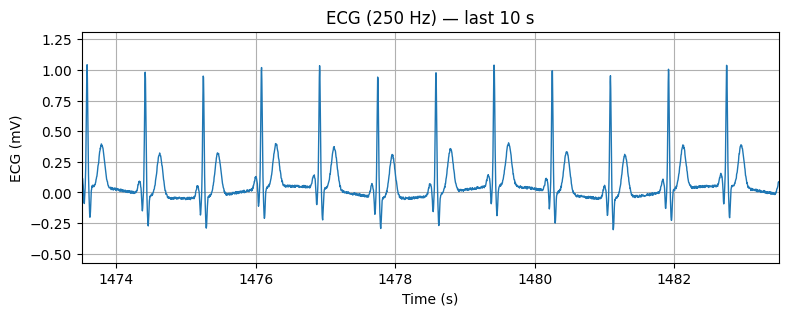

In [ ]:
# Fixed-size NumPy ring buffer live plotter
# Payload: [ float ts_sec | 125 x int16 (µV) ] at 250 Hz

# ---- Stream format ----
FS    = 250            # Hz (matches ESP32)
BATCH = 125            # samples per packet (0.5 s)
BYTES_PER_PKT = 4 + 2*BATCH  # 4 bytes float (time stamp) + 125*int16

# ---- Ring buffer (exactly 10 seconds) ----
WIN_SEC = 10
N = FS * WIN_SEC                           # total samples in the window
t_buf = np.empty(N, dtype=np.float32)      # time (s)
y_buf = np.empty(N, dtype=np.float32)      # ECG (mV)
w = 0                                      # write index
filled = 0                                 # how many valid samples (<= N)

# Precompute relative positions inside a batch (faster)
REL = np.arange(BATCH, dtype=np.float32) / FS

# ---- MQTT callbacks (single-threaded loop) ----
def on_connect(c, u, f, rc):
    print(f"[MQTT] connected rc={rc}")
    c.subscribe(TOPIC)

def on_message(c, u, msg):
    global w, filled
    data = msg.payload
    if len(data) != BYTES_PER_PKT: # just drop the message when it is corrupted
        return
    ts0 = struct.unpack_from("<f", data, 0)[0]               # start time (s)
    # Decode 125x int16 (µV) → vectorized to mV
    batch_uv = np.frombuffer(data, dtype="<i2", offset=4, count=BATCH)
    y_batch = batch_uv.astype(np.float32) / 1000.0
    t_batch = ts0 + REL

    # Write into ring (handle wrap in at most two slices)
    r = N - w
    if BATCH <= r:
        t_buf[w:w+BATCH] = t_batch
        y_buf[w:w+BATCH] = y_batch
    else:
        t_buf[w:N]       = t_batch[:r]
        y_buf[w:N]       = y_batch[:r]
        t_buf[0:BATCH-r] = t_batch[r:]
        y_buf[0:BATCH-r] = y_batch[r:]
    w = (w + BATCH) % N
    filled = min(N, filled + BATCH)

# ---- Build client (no threads; callbacks run in this same loop) ----
client = mqtt.Client()
client.username_pw_set(USER, PWD)
client.tls_set()
client.on_connect = on_connect
client.on_message = on_message
client.connect(BROKER, PORT, keepalive=60)

# ---- Plot setup ----
plt.ioff()
fig, ax = plt.subplots(figsize=(9, 3))
(line,) = ax.plot([], [], lw=1)
ax.set_title("ECG (250 Hz) — last 10 s")
ax.set_xlabel("Time (s)")
ax.set_ylabel("ECG (mV)")
ax.grid(True)

last_redraw = time.time()
REDRAW_EVERY_S = 1.0

print("Streaming… interrupt the cell to stop.")
while True:
    # Process network I/O + fire callbacks here
    client.loop(timeout=0.2)

    now = time.time()
    if (now - last_redraw) >= REDRAW_EVERY_S and filled >= 2:
        if filled < N:
            # Not yet full: just show 0..w
            T = t_buf[:w]
            Y = y_buf[:w]
        else:
            # Full: reorder ring so it's chronological
            if w == 0:
                T = t_buf
                Y = y_buf
            else:
                T = np.concatenate((t_buf[w:], t_buf[:w]))
                Y = np.concatenate((y_buf[w:], y_buf[:w]))

        # Trim to exactly last 10 s (cheap mask)
        t1 = T[-1]
        m = T >= (t1 - WIN_SEC)
        T = T[m]; Y = Y[m]

        line.set_data(T, Y)
        ax.set_xlim(T[0], max(T[-1], T[0] + 1e-3))
        ymin, ymax = float(Y.min()), float(Y.max())
        pad = max(0.1, 0.2*(ymax - ymin) if ymax > ymin else 0.1)
        ax.set_ylim(ymin - pad, ymax + pad)

        clear_output(wait=True)
        display(fig)
        last_redraw = now
